In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import os

In [31]:
df = pd.read_csv("../data/processed/csgo_cleaned_3.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 875112 entries, 0 to 875111
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          875112 non-null  int64  
 1   map                 875112 non-null  str    
 2   round               875112 non-null  int64  
 3   att_team            875112 non-null  str    
 4   vic_team            875112 non-null  str    
 5   att_side            875112 non-null  str    
 6   vic_side            875112 non-null  str    
 7   hp_dmg              875112 non-null  int64  
 8   arm_dmg             875112 non-null  int64  
 9   is_bomb_planted     875112 non-null  bool   
 10  bomb_site           135616 non-null  str    
 11  hitbox              875112 non-null  str    
 12  wp                  875112 non-null  str    
 13  wp_type             875112 non-null  str    
 14  winner_team         875112 non-null  str    
 15  winner_side         875112 non-null  str    


In [32]:
ct = pd.crosstab(df["round_type"], df["att_rank"])
display(ct)
ct2 = pd.crosstab(df["round_type"], df["att_rank"], normalize=1)
display(ct2)

att_rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
round_type,,,,,,,,,,,,,,,,,,
ECO,52,126,141,374,571,2069,8524,14223,24520,27316,26256,26166,29658,26009,17883,15875,5671,641
FORCE_BUY,6,57,112,357,652,2278,7423,12309,18756,18660,15279,13953,13448,10795,7490,6653,2211,388
NORMAL,62,145,271,787,1639,5339,18976,32120,50579,54640,44933,43045,43792,36851,24890,22049,7561,916
PISTOL_ROUND,10,41,53,211,258,877,3427,5442,9133,9531,7995,7498,7755,6595,4558,4001,1376,186
SEMI_ECO,14,32,53,153,269,993,3456,4872,7693,7736,7065,6830,6587,5777,3928,3582,1437,191


att_rank,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
round_type,,,,,,,,,,,,,,,,,,
ECO,0.361111,0.314214,0.223810,0.198725,0.168486,0.179041,0.203894,0.206232,0.221538,0.231721,0.258608,0.268391,0.292947,0.302335,0.304397,0.304352,0.310638,0.276055
FORCE_BUY,0.041667,0.142145,0.177778,0.189692,0.192387,0.197127,0.177558,0.178479,0.169460,0.158293,0.150491,0.143119,0.132833,0.125484,0.127492,0.127550,0.121111,0.167097
NORMAL,0.430556,0.361596,0.430159,0.418172,0.483623,0.462011,0.453906,0.465737,0.456980,0.463510,0.442568,0.441523,0.432556,0.428366,0.423667,0.422719,0.414165,0.394488
PISTOL_ROUND,0.069444,0.102244,0.084127,0.112115,0.076129,0.075891,0.081974,0.078908,0.082516,0.080851,0.078747,0.076909,0.076600,0.076662,0.077584,0.076706,0.075372,0.080103
SEMI_ECO,0.097222,0.079800,0.084127,0.081296,0.079374,0.085929,0.082668,0.070644,0.069506,0.065624,0.069587,0.070057,0.065063,0.067153,0.066861,0.068673,0.078714,0.082257


In [33]:
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(ct)

alpha = 0.05
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.8f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
display(expected_frequencies)

if p_value <= alpha:
    print("Conclusion: Reject H0. The variables are significantly dependent.")
else:
    print("Conclusion: Fail to reject H0. The variables are independent.")

Chi-Square Statistic: 7852.7921
P-value: 0.00000000
Degrees of Freedom: 68
Expected Frequencies:


array([[3.72007240e+01, 1.03593683e+02, 1.62753168e+02, 4.86192796e+02,
        8.75508706e+02, 2.98535810e+03, 1.08000935e+04, 1.78165634e+04,
        2.85931482e+04, 3.04537010e+04, 2.62285771e+04, 2.51859235e+04,
        2.61541757e+04, 2.22240742e+04, 1.51771204e+04, 1.34749289e+04,
        4.71622512e+03, 5.99861675e+02],
       [2.15276307e+01, 5.99484717e+01, 9.41833845e+01, 2.81354174e+02,
        5.06646810e+02, 1.72759237e+03, 6.24988980e+03, 1.03102402e+04,
        1.65465257e+04, 1.76232062e+04, 1.51781757e+04, 1.45748040e+04,
        1.51351204e+04, 1.28608159e+04, 8.78282485e+03, 7.79778625e+03,
        2.72922519e+03, 3.47133046e+02],
       [6.39434495e+01, 1.78064745e+02, 2.79752592e+02, 8.35705361e+02,
        1.50489132e+03, 5.13146182e+03, 1.85640267e+04, 3.06244718e+04,
        4.91480898e+04, 5.23461504e+04, 4.50836843e+04, 4.32914915e+04,
        4.49557974e+04, 3.82004384e+04, 2.60875953e+04, 2.31617384e+04,
        8.10660843e+03, 1.03108812e+03],
       [1.134

Conclusion: Reject H0. The variables are significantly dependent.


In [34]:
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import numpy as np

In [35]:
def cochran_armitage_trend(ranks, n, r, alternative='greater'):
    """
    ranks: numeric score per rank level (e.g. the att_rank values themselves)
    n: total damage entries at that rank
    r: damage entries at that rank using the weapon of interest
    """
    ranks, n, r = map(np.asarray, (ranks, n, r))
    N = n.sum()
    R = r.sum()
    p_bar = R / N
    x_bar = (n * ranks).sum() / N

    numerator = (n * (ranks - x_bar) * (r / n - p_bar)).sum()
    denom = np.sqrt(p_bar * (1 - p_bar) * (n * (ranks - x_bar) ** 2).sum())
    z = numerator / denom

    if alternative == 'greater':
        p_value = 1 - stats.norm.cdf(z)
    elif alternative == 'less':
        p_value = stats.norm.cdf(z)
    else:
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return z, p_value


# --- Build the (att_rank, wp) contingency counts ---
# total damage entries per rank (denominator) — across ALL weapons
total_by_rank = df.groupby('att_rank').size().rename('n_total')

# damage entries per (rank, weapon) — numerator
usage_by_rank_wp = df.groupby(['att_rank', 'wp']).size().rename('n_wp').reset_index()

# fill in zeros for weapon/rank combos that never occur
all_ranks = df['att_rank'].unique()
all_weapons = df['wp'].unique()
full_grid = pd.MultiIndex.from_product([all_ranks, all_weapons], names=['att_rank', 'wp']).to_frame(index=False)

counts = (full_grid
          .merge(usage_by_rank_wp, on=['att_rank', 'wp'], how='left')
          .fillna({'n_wp': 0}))
counts = counts.merge(total_by_rank, on='att_rank', how='left')
counts['n_wp'] = counts['n_wp'].astype(int)

def run_ca_for_weapon(counts, weapon, alternative='greater'):
    sub = counts[counts['wp'] == weapon].sort_values('att_rank')
    z, p = cochran_armitage_trend(sub['att_rank'].values, sub['n_total'].values,
                                   sub['n_wp'].values, alternative=alternative)
    N = sub['n_total'].sum()
    effect_r = z / np.sqrt(N) if N > 0 else np.nan

    # logistic regression slope -> odds ratio per rank unit
    X = sm.add_constant(sub['att_rank'].astype(float))
    y_prop = sub['n_wp'] / sub['n_total']
    try:
        model = sm.GLM(y_prop, X, family=sm.families.Binomial(),
                        freq_weights=sub['n_total'].values).fit()
        odds_ratio = np.exp(model.params['att_rank'])
    except Exception:
        odds_ratio = np.nan

    return z, p, effect_r, odds_ratio


results = []
for weapon in df['wp'].unique():
    z, p, r, orr = run_ca_for_weapon(counts, weapon, alternative='greater')
    results.append({'wp': weapon, 'z': z, 'p_raw': p, 'effect_r': r, 'odds_ratio_per_rank': orr})

res_df = pd.DataFrame(results).dropna(subset=['p_raw'])
res_df['p_adj'] = multipletests(res_df['p_raw'], method='fdr_bh')[1]
res_df = res_df.sort_values('effect_r', ascending=False)  # sort by effect size, not p
print(res_df)

              wp          z         p_raw  effect_r  odds_ratio_per_rank  \
1           AK47  41.698680  0.000000e+00  0.044575             1.038876   
2             HE  38.843866  0.000000e+00  0.041523             1.082247   
19        Deagle  29.952190  0.000000e+00  0.032018             1.077430   
14          P250  28.014611  0.000000e+00  0.029947             1.068078   
28            CZ  27.757912  0.000000e+00  0.029673             1.111316   
7            AWP  23.407552  0.000000e+00  0.025022             1.046492   
3           M4A4  16.913518  0.000000e+00  0.018080             1.023207   
23     FiveSeven  15.895690  0.000000e+00  0.016992             1.047436   
0     Incendiary  15.334445  0.000000e+00  0.016392             1.029140   
22         Famas   7.827564  2.442491e-15  0.008367             1.021392   
26          Tec9   5.980571  1.111786e-09  0.006393             1.021625   
31         Smoke   4.723892  1.156864e-06  0.005050             1.071266   
5          S

In [36]:
# --- Build the (att_rank, wp) contingency counts ---
# total damage entries per rank (denominator) — across ALL weapons
total_by_rank = df.groupby('att_rank').size().rename('n_total')

# damage entries per (rank, weapon) — numerator
usage_by_rank_rt = df.groupby(['att_rank', 'round_type']).size().rename('n_rt').reset_index()

# fill in zeros for weapon/rank combos that never occur
all_ranks = df['att_rank'].unique()
all_weapons = df['round_type'].unique()
full_grid = pd.MultiIndex.from_product([all_ranks, all_weapons], names=['att_rank', 'round_type']).to_frame(index=False)

counts = (full_grid
          .merge(usage_by_rank_rt, on=['att_rank', 'round_type'], how='left')
          .fillna({'n_rt': 0}))
counts = counts.merge(total_by_rank, on='att_rank', how='left')
counts['n_rt'] = counts['n_rt'].astype(int)

def run_ca_for_rt(counts, round_type, alternative='greater'):
    sub = counts[counts['round_type'] == round_type].sort_values('att_rank')
    z, p = cochran_armitage_trend(sub['att_rank'].values, sub['n_total'].values,
                                   sub['n_rt'].values, alternative=alternative)
    N = sub['n_total'].sum()
    effect_r = z / np.sqrt(N) if N > 0 else np.nan

    # logistic regression slope -> odds ratio per rank unit
    X = sm.add_constant(sub['att_rank'].astype(float))
    y_prop = sub['n_rt'] / sub['n_total']
    try:
        model = sm.GLM(y_prop, X, family=sm.families.Binomial(),
                        freq_weights=sub['n_total'].values).fit()
        odds_ratio = np.exp(model.params['att_rank'])
    except Exception:
        odds_ratio = np.nan

    return z, p, effect_r, odds_ratio


results = []
for round_type in df['round_type'].unique():
    z, p, r, orr = run_ca_for_rt(counts, round_type, alternative='greater')
    results.append({'round_type': round_type, 'z': z, 'p_raw': p, 'effect_r': r, 'odds_ratio_per_rank': orr})

res_df = pd.DataFrame(results).dropna(subset=['p_raw'])
res_df['p_adj'] = multipletests(res_df['p_raw'], method='fdr_bh')[1]
res_df = res_df.sort_values('effect_r', ascending=False)  # sort by effect size, not p
print(res_df)

     round_type          z  p_raw  effect_r  odds_ratio_per_rank  p_adj
2           ECO  76.922667    0.0  0.082229             1.071208    0.0
1  PISTOL_ROUND  -6.214727    1.0 -0.006643             0.991042    1.0
4      SEMI_ECO  -6.821529    1.0 -0.007292             0.989578    1.0
0        NORMAL -26.253121    1.0 -0.028064             0.979597    1.0
3     FORCE_BUY -48.291075    1.0 -0.051622             0.948294    1.0


In [37]:
import sys

Jonckheere-Terpstra Test Summary
Groups (in order):  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Total N:             875,112

Sample size per group:
       1:        144  ( 0.0%)
       2:        401  ( 0.0%)
       3:        630  ( 0.1%)
       4:      1,882  ( 0.2%)
       5:      3,389  ( 0.4%)
       6:     11,556  ( 1.3%)
       7:     41,806  ( 4.8%)
       8:     68,966  ( 7.9%)
       9:    110,681  (12.6%)
      10:    117,883  (13.5%)
      11:    101,528  (11.6%)
      12:     97,492  (11.1%)
      13:    101,240  (11.6%)
      14:     86,027  ( 9.8%)
      15:     58,749  ( 6.7%)
      16:     52,160  ( 6.0%)
      17:     18,256  ( 2.1%)
      18:      2,322  ( 0.3%)

J statistic:         179,314,535,684.5
z-score:             51.98
p-value (asymptotic):  < 0.0001

Interpreta

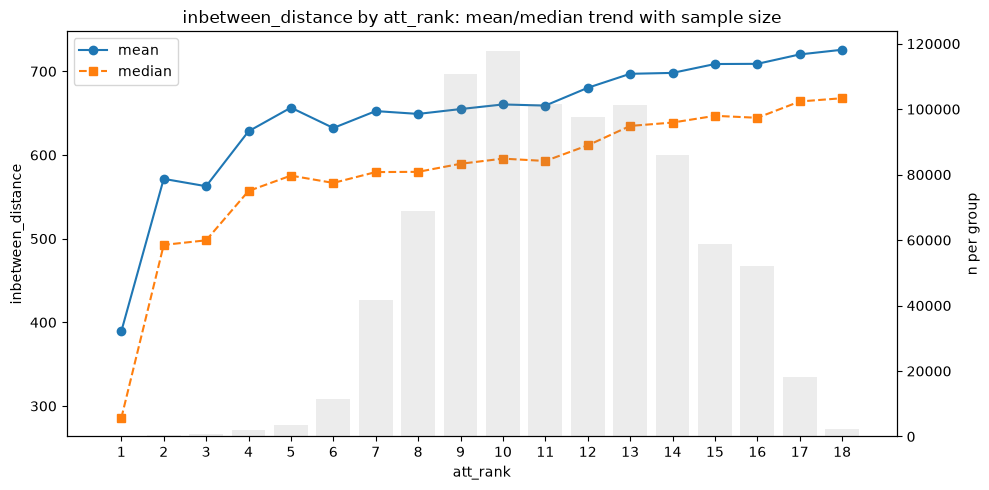

In [38]:
sys.path.insert(0, "../src") 
from jt_test import jonckheere_terpstra
from jt_summary import summarize_jt, plot_trend

result = jonckheere_terpstra(df, "inbetween_distance", "att_rank",
                              group_order=sorted(df["att_rank"].unique()))
print(summarize_jt(result))

fig, stats_table = plot_trend(df, "inbetween_distance", "att_rank")
fig.savefig("../images/05_jt_trend.png")
print(stats_table)